IMPORT LIBRARIES 

In [22]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

CONNECT TO WEBSITE 

In [2]:
url = "https://books.toscrape.com/"
response = requests.get(url)
print(response.status_code)

200


READ HTML

In [3]:
soup = BeautifulSoup(response.text, "html.parser")

print(soup.title.text)


    All products | Books to Scrape - Sandbox



FIND BOOK INFORMTAION


In [4]:
books = soup.find_all("article", class_="product_pod")

print(len(books))

20


EXTRACT DATA

In [5]:
data = []

for book in books:
    
    title = book.h3.a["title"]
    
    price = book.find("p", class_="price_color").text
    
    availability = book.find("p", class_="instock availability").text.strip()
    
    rating = book.p["class"][1]
    
    data.append([title, price, availability, rating])

print(data[:3])

[['A Light in the Attic', 'Â£51.77', 'In stock', 'Three'], ['Tipping the Velvet', 'Â£53.74', 'In stock', 'One'], ['Soumission', 'Â£50.10', 'In stock', 'One']]


CREATE DATAFRAME

In [6]:
df = pd.DataFrame(
    data,
    columns=["Title", "Price", "Availability", "Rating"]
)

df.head()

,Title,Price,Availability,Rating
0,A Light in the Attic,Â£51.77,In stock,Three
1,Tipping the Velvet,Â£53.74,In stock,One
2,Soumission,Â£50.10,In stock,One
3,Sharp Objects,Â£47.82,In stock,Four
4,Sapiens: A Brief History of Humankind,Â£54.23,In stock,Five


SAVE DATASET

In [7]:

df.to_csv("books_dataset.csv", index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully


NO CODE TOOLS (OCTOPARSE / PARSEHUB)

OCTROPARSE WEB SCRAPER:

How it works:

You open the website inside the tool

Click on elements (title, price, etc.)

It automatically detects patterns

You export CSV/Excel

PROS:

No coding required

Fast for simple websites

Good for beginners

CONS:

Limited flexibility

Breaks on complex websites

Looks less impressive for technical internships

PARSEHUB SCRAPER:

How it works:

Visual point-and-click selection

Can handle pagination

Can scrape multiple pages

PROS:

Easier UI than Octoparse

Good for structured websites

Handles moderate complexity

CONS:

Still not “engineering skill”

Limited control compared to Python

Exploratory Data Analysis

In [17]:
#Missing Value
df.isnull().sum()

Title           0
Price           0
Availability    0
Rating          0
dtype: int64

In [19]:
#RATING IN TEXT 
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["Rating"] = df["Rating"].map(rating_map)

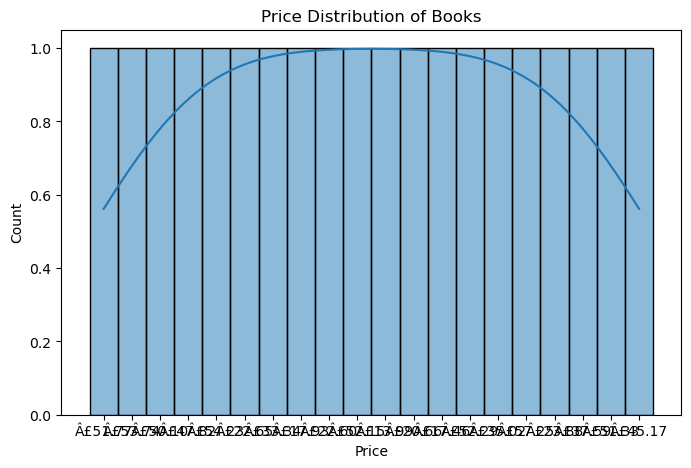

In [25]:
#PRICE DISTRIBUTION
plt.figure(figsize=(8,5))
sns.histplot(df["Price"], bins=5, kde=True)
plt.title("Price Distribution of Books")
plt.show()

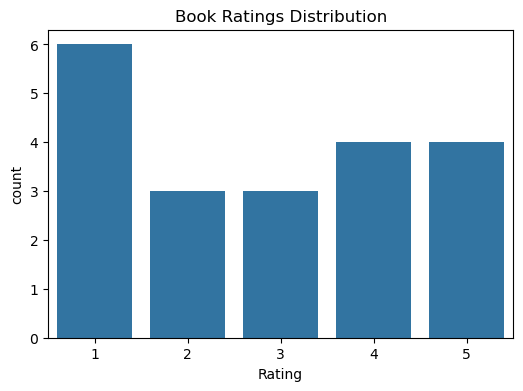

In [26]:
#Rating Count
plt.figure(figsize=(6,4))
sns.countplot(x="Rating", data=df)
plt.title("Book Ratings Distribution")
plt.show()

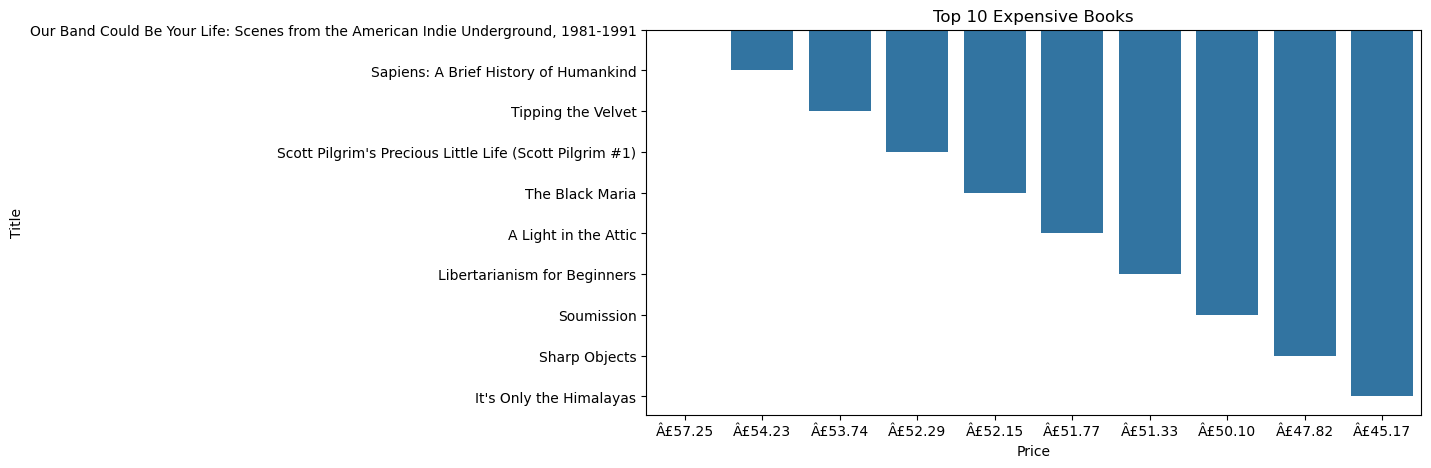

In [27]:
#TOP 10 EXPENSVIE BOOK
top_books = df.sort_values("Price", ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x="Price", y="Title", data=top_books)
plt.title("Top 10 Expensive Books")
plt.show()